In [1]:
using CUDA, Random, LinearAlgebra, NeuroDSL

# Vérifier les GPUs disponibles
devices = collect(CUDA.devices())
@assert length(devices) >= 2 "Il faut au moins 2 GPUs"

println("✅ GPUs détectés :")
for (i, dev) in enumerate(devices)
    println("   GPU $i : $(CUDA.name(dev))")
end

# Indices des GPUs
gpu1_idx = 0
gpu2_idx = 1

function set_gpu(gpu_idx)
    CUDA.device!(gpu_idx)
    println("🔧 GPU actif : $(CUDA.name(CUDA.device()))")
end

# Test rapide d'allocation
set_gpu(gpu1_idx)
a = CUDA.rand(Float32, 2, 2)
set_gpu(gpu2_idx)
b = CUDA.rand(Float32, 2, 2)
println("✅ Test d'allocation réussi sur les deux GPUs.")

✅ GPUs détectés :
   GPU 1 : NVIDIA RTX A5500 Laptop GPU
   GPU 2 : NVIDIA GeForce RTX 3060 Ti
🔧 GPU actif : NVIDIA RTX A5500 Laptop GPU
🔧 GPU actif : NVIDIA GeForce RTX 3060 Ti
✅ Test d'allocation réussi sur les deux GPUs.


In [6]:
# Structure du modèle
mutable struct ParallelModel
    W1::CuArray{Float32,2}
    W2::CuArray{Float32,2}
    m1_W1::CuArray{Float32,2}
    m2_W1::CuArray{Float32,2}
    m1_W2::CuArray{Float32,2}
    m2_W2::CuArray{Float32,2}
end

function init_model_on_gpu(gpu_idx::Int, d_in::Int, d_hidden::Int, d_out::Int)
    set_gpu(gpu_idx)
    W1 = CUDA.randn(Float32, d_hidden, d_in) .* sqrt(2.0f0 / d_in)
    W2 = CUDA.randn(Float32, d_out, d_hidden) .* sqrt(2.0f0 / d_hidden)
    m1_W1 = CUDA.zeros(Float32, d_hidden, d_in)
    m2_W1 = CUDA.zeros(Float32, d_hidden, d_in)
    m1_W2 = CUDA.zeros(Float32, d_out, d_hidden)
    m2_W2 = CUDA.zeros(Float32, d_out, d_hidden)
    return ParallelModel(W1, W2, m1_W1, m2_W1, m1_W2, m2_W2)
end

# Initialiser puis synchroniser les poids
model1 = init_model_on_gpu(gpu1_idx, 784, 128, 10)
model2 = init_model_on_gpu(gpu2_idx, 784, 128, 10)

set_gpu(gpu1_idx)
w1_cpu = Array(model1.W1)
w2_cpu = Array(model1.W2)
set_gpu(gpu2_idx)
copyto!(model2.W1, CuArray(w1_cpu))
copyto!(model2.W2, CuArray(w2_cpu))
println("✅ Modèles initialisés et synchronisés sur GPU1 et GPU2")

🔧 GPU actif : NVIDIA RTX A5500 Laptop GPU
🔧 GPU actif : NVIDIA GeForce RTX 3060 Ti
🔧 GPU actif : NVIDIA RTX A5500 Laptop GPU
🔧 GPU actif : NVIDIA GeForce RTX 3060 Ti
✅ Modèles initialisés et synchronisés sur GPU1 et GPU2


In [13]:
using MLDatasets: MNIST
using Statistics

function load_mnist_batches(batch_size::Int)
    train_x, train_y = MNIST(split=:train)[:]
    X = Float32.(reshape(train_x, 28*28, :))' / 255.0f0   # (60000, 784)
    Y = zeros(Float32, size(X,1), 10)
    for i in 1:length(train_y)
        Y[i, train_y[i]+1] = 1.0f0
    end
    # Shuffle
    n = size(X,1)
    idx = shuffle(1:n)
    X = X[idx, :]
    Y = Y[idx, :]
    # Création des batches (CPU)
    x_batches = [X[i:min(i+batch_size-1, n), :] for i in 1:batch_size:n]
    y_batches = [Y[i:min(i+batch_size-1, n), :] for i in 1:batch_size:n]
    return x_batches, y_batches
end

function split_batch_for_cpu(x::Matrix{Float32}, y::Matrix{Float32})
    half = div(size(x,1), 2)
    x1 = x[1:half, :]
    y1 = y[1:half, :]
    x2 = x[half+1:end, :]
    y2 = y[half+1:end, :]
    return (x1, y1), (x2, y2)
end

batch_size = 256
x_batches, y_batches = load_mnist_batches(batch_size)
println("✅ MNIST chargé : $(length(x_batches)) batches de taille $batch_size")

✅ MNIST chargé : 235 batches de taille 256


In [14]:
# Forward / backward manuels (pas de NeuroDSL ici pour garder le contrôle)
function forward_gpu!(model::ParallelModel, X::CuArray{Float32,2})
    h = X * model.W1'                 # (batch, 128)
    h = max.(0.0f0, h)               # ReLU
    logits = h * model.W2'           # (batch, 10)
    return logits, h
end

function softmax(x::CuArray{Float32,2})
    max_x = maximum(x, dims=2)
    exp_x = exp.(x .- max_x)
    return exp_x ./ sum(exp_x, dims=2)
end

function compute_loss(probs::CuArray{Float32,2}, Y::CuArray{Float32,2})
    batch_size = size(probs, 1)
    loss = -sum(Y .* log.(probs .+ 1f-8)) / batch_size
    return loss
end

function backward_gpu!(model::ParallelModel, X::CuArray{Float32,2},
                       Y::CuArray{Float32,2}, logits::CuArray{Float32,2},
                       h::CuArray{Float32,2})
    batch_size = size(X, 1)
    probs = softmax(logits)
    d_logits = (probs - Y) ./ Float32(batch_size)
    dW2 = d_logits' * h
    d_h = d_logits * model.W2
    d_h .= d_h .* (h .> 0.0f0)
    dW1 = d_h' * X
    return dW1, dW2
end

println("✅ Fonctions forward/backward définies")

✅ Fonctions forward/backward définies


In [15]:
# Boucle d'entraînement utilisant AdamW de NeuroDSL
function train_parallel!(model1, model2, x_batches, y_batches, X_test, Y_test, lr, epochs)
    losses = Float32[]
    accs = Float32[]
    for epoch in 1:epochs
        epoch_loss = 0.0f0
        for i in 1:length(x_batches)
            (x1_cpu, y1_cpu), (x2_cpu, y2_cpu) = split_batch_for_cpu(x_batches[i], y_batches[i])

            # GPU 1
            CUDA.device!(gpu1_idx)
            x1 = CuArray(x1_cpu)
            y1 = CuArray(y1_cpu)
            logits1, h1 = forward_gpu!(model1, x1)
            loss1 = compute_loss(softmax(logits1), y1)
            dW1_1, dW2_1 = backward_gpu!(model1, x1, y1, logits1, h1)

            # GPU 2
            CUDA.device!(gpu2_idx)
            x2 = CuArray(x2_cpu)
            y2 = CuArray(y2_cpu)
            logits2, h2 = forward_gpu!(model2, x2)
            loss2 = compute_loss(softmax(logits2), y2)
            dW1_2, dW2_2 = backward_gpu!(model2, x2, y2, logits2, h2)

            # Moyenne des gradients sur CPU
            dW1_avg = (Array(dW1_1) .+ Array(dW1_2)) ./ 2.0f0
            dW2_avg = (Array(dW2_1) .+ Array(dW2_2)) ./ 2.0f0

            # Mise à jour GPU1 (NeuroDSL)
            CUDA.device!(gpu1_idx)
            adamw_step!(Backend.CPUDevice(), model1.W1, CuArray(dW1_avg),
                        model1.m1_W1, model1.m2_W1, lr, 0.9f0, 0.999f0, 1f-8,
                        Int32(epoch * length(x_batches) + i), 1.0f0, 0.01f0)
            adamw_step!(Backend.CPUDevice(), model1.W2, CuArray(dW2_avg),
                        model1.m1_W2, model1.m2_W2, lr, 0.9f0, 0.999f0, 1f-8,
                        Int32(epoch * length(x_batches) + i), 1.0f0, 0.01f0)

            # Mise à jour GPU2 (NeuroDSL)
            CUDA.device!(gpu2_idx)
            adamw_step!(Backend.CPUDevice(), model2.W1, CuArray(dW1_avg),
                        model2.m1_W1, model2.m2_W1, lr, 0.9f0, 0.999f0, 1f-8,
                        Int32(epoch * length(x_batches) + i), 1.0f0, 0.01f0)
            adamw_step!(Backend.CPUDevice(), model2.W2, CuArray(dW2_avg),
                        model2.m1_W2, model2.m2_W2, lr, 0.9f0, 0.999f0, 1f-8,
                        Int32(epoch * length(x_batches) + i), 1.0f0, 0.01f0)

            epoch_loss += (loss1 + loss2) / 2.0f0
        end

        avg_loss = epoch_loss / length(x_batches)
        push!(losses, avg_loss)

        # Évaluation sur le test set
        acc = accuracy(model1, X_test, Y_test)  # model1 et model2 sont identiques
        push!(accs, acc)

        println("Epoch $epoch | Loss: $avg_loss | Test Accuracy: $(round(acc*100, digits=2))%")
    end
    return losses, accs
end

println("✅ Fonction d'entraînement parallèle (NeuroDSL) définie")

✅ Fonction d'entraînement parallèle (NeuroDSL) définie


In [20]:
function load_mnist_test()
    test_x, test_y = MNIST(split=:test)[:]
    X_test = Float32.(reshape(test_x, 28*28, :))' / 255.0f0
    Y_test = zeros(Float32, size(X_test,1), 10)
    for i in 1:length(test_y)
        Y_test[i, test_y[i]+1] = 1.0f0
    end
    return X_test, Y_test
end

X_test, Y_test = load_mnist_test()
println("✅ Test set chargé : $(size(X_test,1)) exemples")

✅ Test set chargé : 10000 exemples


In [21]:
function accuracy(model::ParallelModel, X::Matrix{Float32}, Y::Matrix{Float32})
    # On évalue sur GPU1 (ou celui que tu veux, les poids sont identiques)
    CUDA.device!(gpu1_idx)
    x = CuArray(X)
    y_labels = [argmax(Y[i,:]) for i in 1:size(Y,1)]  # classes 1..10
    logits, _ = forward_gpu!(model, x)
    preds = map(i -> argmax(logits[i,:]), 1:size(logits,1))
    acc = sum(preds .== y_labels) / length(y_labels)
    return acc
end

accuracy (generic function with 1 method)

In [23]:
println("🚀 Entraînement complet sur 2 GPUs...")
losses, accs = train_parallel!(model1, model2, x_batches, y_batches, X_test, Y_test, 0.001f0, 20)
println("✅ Entraînement terminé")

🚀 Entraînement complet sur 2 GPUs...
Epoch 1 | Loss: 1.6819842 | Test Accuracy: 80.33%
Epoch 2 | Loss: 0.86413723 | Test Accuracy: 85.61%
Epoch 3 | Loss: 0.6108288 | Test Accuracy: 87.89%
Epoch 4 | Loss: 0.49935135 | Test Accuracy: 88.97%
Epoch 5 | Loss: 0.43733802 | Test Accuracy: 89.88%
Epoch 6 | Loss: 0.39839017 | Test Accuracy: 90.43%
Epoch 7 | Loss: 0.37182477 | Test Accuracy: 90.87%
Epoch 8 | Loss: 0.35238478 | Test Accuracy: 91.05%
Epoch 9 | Loss: 0.3368421 | Test Accuracy: 91.17%
Epoch 10 | Loss: 0.3241304 | Test Accuracy: 91.34%
Epoch 11 | Loss: 0.31349057 | Test Accuracy: 91.56%
Epoch 12 | Loss: 0.30432695 | Test Accuracy: 91.78%
Epoch 13 | Loss: 0.2962307 | Test Accuracy: 91.99%
Epoch 14 | Loss: 0.28894982 | Test Accuracy: 92.07%
Epoch 15 | Loss: 0.28226787 | Test Accuracy: 92.3%
Epoch 16 | Loss: 0.27606857 | Test Accuracy: 92.52%
Epoch 17 | Loss: 0.2702441 | Test Accuracy: 92.67%
Epoch 18 | Loss: 0.26473784 | Test Accuracy: 92.74%
Epoch 19 | Loss: 0.25952566 | Test Accuracy

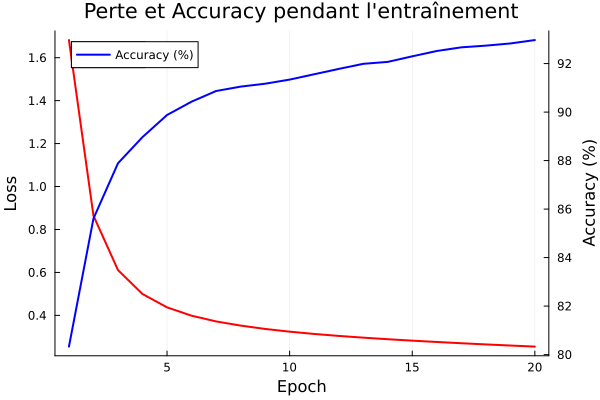

In [25]:
using Plots

function plot_training_combined(losses::Vector{Float32}, accs::Vector{Float32})
    epochs = 1:length(losses)
    
    # Create the plot with loss on the left axis
    p = plot(epochs, losses, 
             label="Loss", 
             xlabel="Epoch", 
             ylabel="Loss",
             color=:red, 
             lw=2, 
             legend=:topleft,
             title="Perte et Accuracy pendant l'entraînement")
    
    # Use twinx() to create a twin axis and plot on it
    plot!(twinx(), epochs, accs .* 100, 
          label="Accuracy (%)", 
          color=:blue, 
          lw=2,
          ylabel="Accuracy (%)")
    
    return p
end

# After training
plot_training_combined(losses, accs)

In [26]:
using CUDA, NeuroDSL, MLDatasets, Statistics, Random

# Hyperparamètres (pour que le calcul soit significatif)
batch_size = 2048       # plus gros batch pour stresser le parallélisme
epochs = 20
lr = 0.001f0

# Vérification des GPUs
gpus = collect(CUDA.devices())
@assert length(gpus) >= 2 "Il faut 2 GPUs"

# Chargement des données (MNIST complet)
train_x, train_y = MNIST(split=:train)[:]
X = Float32.(reshape(train_x, 28*28, :))' / 255.0f0
Y = zeros(Float32, size(X,1), 10)
for i in 1:length(train_y)
    Y[i, train_y[i]+1] = 1.0f0
end
n_samples = size(X,1)
println("✅ Données chargées : $n_samples exemples")

# Initialisation des modèles (réutilise ta structure ParallelModel)
model1 = init_model_on_gpu(gpu1_idx, 784, 128, 10)
model2 = init_model_on_gpu(gpu2_idx, 784, 128, 10)

# Synchronisation des poids initiaux (comme avant)
set_gpu(gpu1_idx)
w1_cpu = Array(model1.W1)
w2_cpu = Array(model1.W2)
set_gpu(gpu2_idx)
copyto!(model2.W1, CuArray(w1_cpu))
copyto!(model2.W2, CuArray(w2_cpu))

# Fonction pour itérer sur des batches (pas de dépendance externe)
function iterate_batches(X::Matrix{Float32}, Y::Matrix{Float32}, bs::Int)
    n = size(X,1)
    shuffle!(collect(1:n))
    return ((X[i:min(i+bs-1,n),:], Y[i:min(i+bs-1,n),:]) for i in 1:bs:n)
end

# Split de batch pour deux GPUs
function split_batch(x::Matrix{Float32}, y::Matrix{Float32})
    half = div(size(x,1), 2)
    (x[1:half,:], y[1:half,:]), (x[half+1:end,:], y[half+1:end,:])
end

# Mesure du temps
println("🚀 Début du benchmark NeuroDSL 2 GPUs...")
start_time = time()

losses = Float32[]
for epoch in 1:epochs
    epoch_loss = 0.0f0
    for (x_batch, y_batch) in iterate_batches(X, Y, batch_size)
        (x1, y1), (x2, y2) = split_batch(x_batch, y_batch)

        # GPU 1
        CUDA.device!(gpu1_idx)
        x1 = CuArray(x1); y1 = CuArray(y1)
        logits1, h1 = forward_gpu!(model1, x1)
        loss1 = compute_loss(softmax(logits1), y1)   
        dW1_1, dW2_1 = backward_gpu!(model1, x1, y1, logits1, h1)

        # GPU 2
        CUDA.device!(gpu2_idx)
        x2 = CuArray(x2); y2 = CuArray(y2)
        logits2, h2 = forward_gpu!(model2, x2)
        loss2 = compute_loss(softmax(logits2), y2) 
        dW1_2, dW2_2 = backward_gpu!(model2, x2, y2, logits2, h2)

        # Moyenne CPU
        dW1_avg = (Array(dW1_1) .+ Array(dW1_2)) ./ 2.0f0
        dW2_avg = (Array(dW2_1) .+ Array(dW2_2)) ./ 2.0f0

        # Mise à jour GPU1 (NeuroDSL)
        CUDA.device!(gpu1_idx)
        adamw_step!(Backend.CPUDevice(), model1.W1, CuArray(dW1_avg),
                    model1.m1_W1, model1.m2_W1, lr, 0.9f0, 0.999f0, 1f-8,
                    Int32(epoch * n_samples ÷ batch_size), 1.0f0, 0.01f0)
        adamw_step!(Backend.CPUDevice(), model1.W2, CuArray(dW2_avg),
                    model1.m1_W2, model1.m2_W2, lr, 0.9f0, 0.999f0, 1f-8,
                    Int32(epoch * n_samples ÷ batch_size), 1.0f0, 0.01f0)

        # Mise à jour GPU2 (NeuroDSL)
        CUDA.device!(gpu2_idx)
        adamw_step!(Backend.CPUDevice(), model2.W1, CuArray(dW1_avg),
                    model2.m1_W1, model2.m2_W1, lr, 0.9f0, 0.999f0, 1f-8,
                    Int32(epoch * n_samples ÷ batch_size), 1.0f0, 0.01f0)
        adamw_step!(Backend.CPUDevice(), model2.W2, CuArray(dW2_avg),
                    model2.m1_W2, model2.m2_W2, lr, 0.9f0, 0.999f0, 1f-8,
                    Int32(epoch * n_samples ÷ batch_size), 1.0f0, 0.01f0)

        epoch_loss += (loss1 + loss2) / 2.0f0
    end
    avg_loss = epoch_loss / (n_samples ÷ batch_size)
    push!(losses, avg_loss)
    println("Epoch $epoch, Loss: $avg_loss")
end

elapsed = time() - start_time
println("✅ Benchmark terminé en $(round(elapsed, digits=2)) secondes")

✅ Données chargées : 60000 exemples
🔧 GPU actif : NVIDIA RTX A5500 Laptop GPU
🔧 GPU actif : NVIDIA GeForce RTX 3060 Ti
🔧 GPU actif : NVIDIA RTX A5500 Laptop GPU
🔧 GPU actif : NVIDIA GeForce RTX 3060 Ti
🚀 Début du benchmark NeuroDSL 2 GPUs...
Epoch 1, Loss: 2.3695207
Epoch 2, Loss: 2.3237228
Epoch 3, Loss: 2.2470412
Epoch 4, Loss: 2.1399362
Epoch 5, Loss: 2.0094466
Epoch 6, Loss: 1.8665601
Epoch 7, Loss: 1.7212993
Epoch 8, Loss: 1.5813024
Epoch 9, Loss: 1.4514171
Epoch 10, Loss: 1.3337777
Epoch 11, Loss: 1.2287443
Epoch 12, Loss: 1.135831
Epoch 13, Loss: 1.0541713
Epoch 14, Loss: 0.9825873
Epoch 15, Loss: 0.91987664
Epoch 16, Loss: 0.86489576
Epoch 17, Loss: 0.8165332
Epoch 18, Loss: 0.7738251
Epoch 19, Loss: 0.73595804
Epoch 20, Loss: 0.70222557
✅ Benchmark terminé en 17.88 secondes


In [27]:
# Benchmark single GPU (GPU1 uniquement)
println("🚀 Benchmark NeuroDSL 1 GPU...")
start_time_single = time()

losses_single = Float32[]
for epoch in 1:epochs
    epoch_loss = 0.0f0
    for (x_batch, y_batch) in iterate_batches(X, Y, batch_size)
        # Tout le batch va sur GPU1 (pas de split)
        CUDA.device!(gpu1_idx)
        x = CuArray(x_batch)
        y = CuArray(y_batch)
        logits, h = forward_gpu!(model1, x)
        loss = compute_loss(softmax(logits), y)
        dW1, dW2 = backward_gpu!(model1, x, y, logits, h)

        # Mise à jour (NeuroDSL)
        adamw_step!(Backend.CPUDevice(), model1.W1, dW1,
                    model1.m1_W1, model1.m2_W1, lr, 0.9f0, 0.999f0, 1f-8,
                    Int32(epoch * n_samples ÷ batch_size), 1.0f0, 0.01f0)
        adamw_step!(Backend.CPUDevice(), model1.W2, dW2,
                    model1.m1_W2, model1.m2_W2, lr, 0.9f0, 0.999f0, 1f-8,
                    Int32(epoch * n_samples ÷ batch_size), 1.0f0, 0.01f0)

        epoch_loss += loss
    end
    avg_loss = epoch_loss / (n_samples ÷ batch_size)
    push!(losses_single, avg_loss)
end

elapsed_single = time() - start_time_single
println("✅ Single GPU : $(round(elapsed_single, digits=2)) s")
println("Speedup (2 GPUs) : $(round(elapsed_single / elapsed, digits=2))x")

🚀 Benchmark NeuroDSL 1 GPU...
✅ Single GPU : 5.08 s
Speedup (2 GPUs) : 0.28x


In [29]:
# ========== 1. Structure du modèle profond ==========
mutable struct DeepParallelModel
    W1::CuArray{Float32,2}  # 2048×784
    W2::CuArray{Float32,2}  # 1024×2048
    W3::CuArray{Float32,2}  # 512×1024
    W4::CuArray{Float32,2}  # 256×512
    W5::CuArray{Float32,2}  # 10×256
    m1_W1::CuArray{Float32,2}
    m2_W1::CuArray{Float32,2}
    m1_W2::CuArray{Float32,2}
    m2_W2::CuArray{Float32,2}
    m1_W3::CuArray{Float32,2}
    m2_W3::CuArray{Float32,2}
    m1_W4::CuArray{Float32,2}
    m2_W4::CuArray{Float32,2}
    m1_W5::CuArray{Float32,2}
    m2_W5::CuArray{Float32,2}
end

# ========== 2. Initialisation He ==========
function init_deep_model(gpu_idx::Int)
    set_gpu(gpu_idx)
    W1 = CUDA.randn(Float32, 4096, 784) .* sqrt(2f0/784)
    W2 = CUDA.randn(Float32, 2048, 4096) .* sqrt(2f0/4096)
    W3 = CUDA.randn(Float32, 1024, 2048) .* sqrt(2f0/2048)
    W4 = CUDA.randn(Float32, 512, 1024)  .* sqrt(2f0/1024)
    W5 = CUDA.randn(Float32, 10, 512)    .* sqrt(2f0/512)
    zeros_like(x) = CUDA.zeros(Float32, size(x))
    return DeepParallelModel(
        W1,W2,W3,W4,W5,
        zeros_like(W1), zeros_like(W1),
        zeros_like(W2), zeros_like(W2),
        zeros_like(W3), zeros_like(W3),
        zeros_like(W4), zeros_like(W4),
        zeros_like(W5), zeros_like(W5)
    )
end

# ========== 3. Synchronisation des poids initiaux ==========
function sync_deep_weights!(m1, m2)
    set_gpu(gpu1_idx)
    w1 = Array(m1.W1); w2 = Array(m1.W2); w3 = Array(m1.W3)
    w4 = Array(m1.W4); w5 = Array(m1.W5)
    set_gpu(gpu2_idx)
    copyto!(m2.W1, CuArray(w1)); copyto!(m2.W2, CuArray(w2))
    copyto!(m2.W3, CuArray(w3)); copyto!(m2.W4, CuArray(w4))
    copyto!(m2.W5, CuArray(w5))
end

# ========== 4. Forward (stocke les activations) ==========
function forward_deep(model::DeepParallelModel, X::CuArray{Float32,2})
    a0 = X                          # batch×784
    z1 = a0 * model.W1'            # batch×2048
    a1 = max.(0f0, z1)
    z2 = a1 * model.W2'            # batch×1024
    a2 = max.(0f0, z2)
    z3 = a2 * model.W3'            # batch×512
    a3 = max.(0f0, z3)
    z4 = a3 * model.W4'            # batch×256
    a4 = max.(0f0, z4)
    logits = a4 * model.W5'        # batch×10
    return logits, (a0, a1, a2, a3, a4)
end

# ========== 5. Backward ==========
function backward_deep(model::DeepParallelModel, X::CuArray{Float32,2},
                       Y::CuArray{Float32,2}, logits::CuArray{Float32,2},
                       cache)
    a0, a1, a2, a3, a4 = cache
    batch = Float32(size(X,1))
    probs = softmax(logits)
    d_logits = (probs - Y) ./ batch

    # Couche 5
    dW5 = d_logits' * a4
    d_a4 = d_logits * model.W5
    d_z4 = d_a4 .* (a4 .> 0f0)
    dW4 = d_z4' * a3

    d_a3 = d_z4 * model.W4
    d_z3 = d_a3 .* (a3 .> 0f0)
    dW3 = d_z3' * a2

    d_a2 = d_z3 * model.W3
    d_z2 = d_a2 .* (a2 .> 0f0)
    dW2 = d_z2' * a1

    d_a1 = d_z2 * model.W2
    d_z1 = d_a1 .* (a1 .> 0f0)
    dW1 = d_z1' * a0

    return (dW1, dW2, dW3, dW4, dW5)
end

# ========== 6. Mise à jour AdamW (NeuroDSL) ==========
function update_deep!(model::DeepParallelModel, grads, lr::Float32, t::Int)
    dW1,dW2,dW3,dW4,dW5 = grads
    β1,β2,ϵ,wd = 0.9f0, 0.999f0, 1f-8, 0.01f0
    for (w, dw, m1, m2) in [
        (model.W1, dW1, model.m1_W1, model.m2_W1),
        (model.W2, dW2, model.m1_W2, model.m2_W2),
        (model.W3, dW3, model.m1_W3, model.m2_W3),
        (model.W4, dW4, model.m1_W4, model.m2_W4),
        (model.W5, dW5, model.m1_W5, model.m2_W5)
    ]
        adamw_step!(Backend.CPUDevice(), w, dw, m1, m2, lr, β1, β2, ϵ, Int32(t), 1f0, wd)
    end
end

# ========== 7. Benchmark ==========
batch_size = 2048
epochs = 20
lr = 0.001f0

# Chargement MNIST (réutilise tes fonctions)
train_x, train_y = MNIST(split=:train)[:]
X = Float32.(reshape(train_x, 28*28, :))' / 255f0
Y = zeros(Float32, size(X,1), 10)
for i in 1:length(train_y)
    Y[i, train_y[i]+1] = 1f0
end
n_samples = size(X,1)

function iterate_batches(X,Y,bs)
    n = size(X,1)
    perm = shuffle(1:n)
    return [(X[perm[i:min(i+bs-1,n)],:], Y[perm[i:min(i+bs-1,n)],:]) for i in 1:bs:n]
end

function split_batch(x,y)
    half = div(size(x,1),2)
    (x[1:half,:], y[1:half,:]), (x[half+1:end,:], y[half+1:end,:])
end

# Modèles
model1 = init_deep_model(gpu1_idx)
model2 = init_deep_model(gpu2_idx)
sync_deep_weights!(model1, model2)

# --- Benchmark 2 GPUs ---
println("🚀 Deep model - 2 GPUs")
start2 = time()
losses2 = Float32[]
for epoch in 1:epochs
    epoch_loss = 0f0
    batches = iterate_batches(X, Y, batch_size)
    for (x_batch, y_batch) in batches
        (x1,y1), (x2,y2) = split_batch(x_batch, y_batch)
        # GPU1
        CUDA.device!(gpu1_idx)
        log1, cache1 = forward_deep(model1, CuArray(x1))
        loss1 = compute_loss(softmax(log1), CuArray(y1))
        g1 = backward_deep(model1, CuArray(x1), CuArray(y1), log1, cache1)
        # GPU2
        CUDA.device!(gpu2_idx)
        log2, cache2 = forward_deep(model2, CuArray(x2))
        loss2 = compute_loss(softmax(log2), CuArray(y2))
        g2 = backward_deep(model2, CuArray(x2), CuArray(y2), log2, cache2)
        # Moyenne CPU
        avg_g = [(Array(a).+Array(b))./2f0 for (a,b) in zip(g1,g2)]
        # Appliquer
        CUDA.device!(gpu1_idx)
        update_deep!(model1, [CuArray(g) for g in avg_g], lr, epoch*length(batches)+1)
        CUDA.device!(gpu2_idx)
        update_deep!(model2, [CuArray(g) for g in avg_g], lr, epoch*length(batches)+1)
        epoch_loss += (loss1+loss2)/2f0
    end
    avg = epoch_loss / length(batches)
    push!(losses2, avg)
    println("Epoch $epoch Loss $avg")
end
t2 = time() - start2
println("✅ 2 GPUs : $(round(t2, digits=2)) s")

# --- Benchmark 1 GPU (GPU1) ---
println("🚀 Deep model - 1 GPU")
model1 = init_deep_model(gpu1_idx)  # réinitialiser
start1 = time()
losses1 = Float32[]
for epoch in 1:epochs
    epoch_loss = 0f0
    batches = iterate_batches(X, Y, batch_size)
    for (x_batch, y_batch) in batches
        CUDA.device!(gpu1_idx)
        x = CuArray(x_batch); y = CuArray(y_batch)
        log, cache = forward_deep(model1, x)
        loss = compute_loss(softmax(log), y)
        g = backward_deep(model1, x, y, log, cache)
        update_deep!(model1, g, lr, epoch*length(batches)+1)
        epoch_loss += loss
    end
    avg = epoch_loss / length(batches)
    push!(losses1, avg)
    println("Epoch $epoch Loss $avg")
end
t1 = time() - start1
println("✅ 1 GPU : $(round(t1, digits=2)) s")
println("🚀 Speedup : $(round(t1/t2, digits=2))x")

🔧 GPU actif : NVIDIA RTX A5500 Laptop GPU
🔧 GPU actif : NVIDIA GeForce RTX 3060 Ti
🔧 GPU actif : NVIDIA RTX A5500 Laptop GPU
🔧 GPU actif : NVIDIA GeForce RTX 3060 Ti
🚀 Deep model - 2 GPUs
Epoch 1 Loss 1.0626805
Epoch 2 Loss 0.3288699
Epoch 3 Loss 0.22222868
Epoch 4 Loss 0.16431871
Epoch 5 Loss 0.12751268
Epoch 6 Loss 0.10255233
Epoch 7 Loss 0.08127947
Epoch 8 Loss 0.064442664
Epoch 9 Loss 0.05295061
Epoch 10 Loss 0.04840289
Epoch 11 Loss 0.04751132
Epoch 12 Loss 0.034569666
Epoch 13 Loss 0.031448938
Epoch 14 Loss 0.02858684
Epoch 15 Loss 0.028190248
Epoch 16 Loss 0.01822261
Epoch 17 Loss 0.014720101
Epoch 18 Loss 0.012205068
Epoch 19 Loss 0.012416357
Epoch 20 Loss 0.011361388
✅ 2 GPUs : 107.96 s
🚀 Deep model - 1 GPU
🔧 GPU actif : NVIDIA RTX A5500 Laptop GPU
Epoch 1 Loss 1.0563126
Epoch 2 Loss 0.32535127
Epoch 3 Loss 0.22305876
Epoch 4 Loss 0.16461585
Epoch 5 Loss 0.12815437
Epoch 6 Loss 0.10360451
Epoch 7 Loss 0.08557286
Epoch 8 Loss 0.066431
Epoch 9 Loss 0.05643516
Epoch 10 Loss 0.052

In [30]:
# ========== 0. Imports ==========
using CUDA, NeuroDSL, MLDatasets, Statistics, Random

# ========== 1. Vérification des GPUs ==========
devices = collect(CUDA.devices())
@assert length(devices) >= 2 "Il faut au moins 2 GPUs"
gpu1_idx = 0
gpu2_idx = 1

function set_gpu(idx)
    CUDA.device!(idx)
    # println("🔧 GPU actif : $(CUDA.name(CUDA.device()))")
end

# ========== 2. Modèle profond ==========
mutable struct DeepParallelModel
    W1::CuArray{Float32,2}  # 4096×784
    W2::CuArray{Float32,2}  # 2048×4096
    W3::CuArray{Float32,2}  # 1024×2048
    W4::CuArray{Float32,2}  # 512×1024
    W5::CuArray{Float32,2}  # 10×512
    m1_W1::CuArray{Float32,2}
    m2_W1::CuArray{Float32,2}
    m1_W2::CuArray{Float32,2}
    m2_W2::CuArray{Float32,2}
    m1_W3::CuArray{Float32,2}
    m2_W3::CuArray{Float32,2}
    m1_W4::CuArray{Float32,2}
    m2_W4::CuArray{Float32,2}
    m1_W5::CuArray{Float32,2}
    m2_W5::CuArray{Float32,2}
end

# ========== 3. Initialisation He ==========
function init_deep_model(gpu_idx::Int)
    set_gpu(gpu_idx)
    W1 = CUDA.randn(Float32, 4096, 784) .* sqrt(2f0/784)
    W2 = CUDA.randn(Float32, 2048, 4096) .* sqrt(2f0/4096)
    W3 = CUDA.randn(Float32, 1024, 2048) .* sqrt(2f0/2048)
    W4 = CUDA.randn(Float32, 512, 1024)  .* sqrt(2f0/1024)
    W5 = CUDA.randn(Float32, 10, 512)    .* sqrt(2f0/512)
    zeros_like(x) = CUDA.zeros(Float32, size(x))
    return DeepParallelModel(
        W1,W2,W3,W4,W5,
        zeros_like(W1), zeros_like(W1),
        zeros_like(W2), zeros_like(W2),
        zeros_like(W3), zeros_like(W3),
        zeros_like(W4), zeros_like(W4),
        zeros_like(W5), zeros_like(W5)
    )
end

# ========== 4. Synchronisation des poids entre deux modèles ==========
function sync_weights!(m1, m2)
    set_gpu(gpu1_idx)
    w1 = Array(m1.W1); w2 = Array(m1.W2); w3 = Array(m1.W3)
    w4 = Array(m1.W4); w5 = Array(m1.W5)
    set_gpu(gpu2_idx)
    copyto!(m2.W1, CuArray(w1)); copyto!(m2.W2, CuArray(w2))
    copyto!(m2.W3, CuArray(w3)); copyto!(m2.W4, CuArray(w4))
    copyto!(m2.W5, CuArray(w5))
end

# ========== 5. Forward & backward manuels ==========
function softmax(x::CuArray{Float32,2})
    max_x = maximum(x, dims=2)
    exp_x = exp.(x .- max_x)
    return exp_x ./ sum(exp_x, dims=2)
end

function compute_loss(probs::CuArray{Float32,2}, Y::CuArray{Float32,2})
    batch = Float32(size(probs,1))
    -sum(Y .* log.(probs .+ 1f-8)) / batch
end

function forward_deep(model::DeepParallelModel, X::CuArray{Float32,2})
    a0 = X
    z1 = a0 * model.W1'
    a1 = max.(0f0, z1)
    z2 = a1 * model.W2'
    a2 = max.(0f0, z2)
    z3 = a2 * model.W3'
    a3 = max.(0f0, z3)
    z4 = a3 * model.W4'
    a4 = max.(0f0, z4)
    logits = a4 * model.W5'
    return logits, (a0, a1, a2, a3, a4)
end

function backward_deep(model::DeepParallelModel, X::CuArray{Float32,2},
                       Y::CuArray{Float32,2}, logits::CuArray{Float32,2}, cache)
    a0, a1, a2, a3, a4 = cache
    batch = Float32(size(X,1))
    probs = softmax(logits)
    d_logits = (probs - Y) ./ batch

    dW5 = d_logits' * a4
    d_a4 = d_logits * model.W5
    d_z4 = d_a4 .* (a4 .> 0f0)
    dW4 = d_z4' * a3

    d_a3 = d_z4 * model.W4
    d_z3 = d_a3 .* (a3 .> 0f0)
    dW3 = d_z3' * a2

    d_a2 = d_z3 * model.W3
    d_z2 = d_a2 .* (a2 .> 0f0)
    dW2 = d_z2' * a1

    d_a1 = d_z2 * model.W2
    d_z1 = d_a1 .* (a1 .> 0f0)
    dW1 = d_z1' * a0

    return (dW1, dW2, dW3, dW4, dW5)
end

# ========== 6. Mise à jour AdamW avec NeuroDSL ==========
function update_deep!(model::DeepParallelModel, grads, lr::Float32, t::Int)
    dW1,dW2,dW3,dW4,dW5 = grads
    β1,β2,ϵ,wd = 0.9f0, 0.999f0, 1f-8, 0.01f0
    for (w, dw, m1, m2) in [
        (model.W1, dW1, model.m1_W1, model.m2_W1),
        (model.W2, dW2, model.m1_W2, model.m2_W2),
        (model.W3, dW3, model.m1_W3, model.m2_W3),
        (model.W4, dW4, model.m1_W4, model.m2_W4),
        (model.W5, dW5, model.m1_W5, model.m2_W5)
    ]
        adamw_step!(Backend.CPUDevice(), w, dw, m1, m2, lr, β1, β2, ϵ, Int32(t), 1f0, wd)
    end
end

# ========== 7. Chargement des données ==========
function load_mnist()
    train_x, train_y = MNIST(split=:train)[:]
    X = Float32.(reshape(train_x, 28*28, :))' / 255f0
    Y = zeros(Float32, size(X,1), 10)
    for i in 1:length(train_y)
        Y[i, train_y[i]+1] = 1f0
    end
    return X, Y
end

function iterate_batches(X, Y, bs)
    n = size(X,1)
    perm = shuffle(1:n)
    batches = []
    for i in 1:bs:n
        push!(batches, (X[perm[i:min(i+bs-1,n)],:], Y[perm[i:min(i+bs-1,n)],:]))
    end
    return batches
end

function split_batch(x, y)
    half = div(size(x,1), 2)
    (x[1:half,:], y[1:half,:]), (x[half+1:end,:], y[half+1:end,:])
end

X, Y = load_mnist()
println("✅ MNIST chargé : $(size(X,1)) exemples")

# ========== 8. Hyperparamètres ==========
batch_size = 2048
epochs = 20
lr = 0.001f0

# ========== 9. Benchmark 1 GPU ==========
println("\n🚀 Deep model - 1 GPU")
model1 = init_deep_model(gpu1_idx)
start1 = time()
losses1 = Float32[]
for epoch in 1:epochs
    epoch_loss = 0f0
    batches = iterate_batches(X, Y, batch_size)
    for (x_batch, y_batch) in batches
        set_gpu(gpu1_idx)
        x = CuArray(x_batch); y = CuArray(y_batch)
        log, cache = forward_deep(model1, x)
        loss = compute_loss(softmax(log), y)
        grads = backward_deep(model1, x, y, log, cache)
        update_deep!(model1, grads, lr, epoch*length(batches)+1)
        epoch_loss += loss
    end
    avg = epoch_loss / length(batches)
    push!(losses1, avg)
    println("Epoch $epoch Loss $avg")
end
t1 = time() - start1
println("✅ 1 GPU : $(round(t1, digits=2)) s")

# ========== 10. Benchmark 2 GPUs asynchrone ==========
println("\n🚀 Deep model - 2 GPUs (asynchrone)")
model1 = init_deep_model(gpu1_idx)
model2 = init_deep_model(gpu2_idx)
sync_weights!(model1, model2)

# Fonction exécutée dans une tâche asynchrone
function gpu_task!(model, x, y, gpu_idx, loss_chan, grad_chan)
    set_gpu(gpu_idx)
    xg = CuArray(x)
    yg = CuArray(y)
    log, cache = forward_deep(model, xg)
    loss = compute_loss(softmax(log), yg)
    grads = backward_deep(model, xg, yg, log, cache)
    put!(loss_chan, loss)
    put!(grad_chan, grads)
end

start2 = time()
losses2 = Float32[]
for epoch in 1:epochs
    epoch_loss = 0f0
    batches = iterate_batches(X, Y, batch_size)
    for (x_batch, y_batch) in batches
        (x1,y1), (x2,y2) = split_batch(x_batch, y_batch)

        # Canaux pour résultats
        loss1_chan = Channel{Float32}(1)
        loss2_chan = Channel{Float32}(1)
        grad1_chan = Channel{NTuple{5,CuArray{Float32,2}}}(1)
        grad2_chan = Channel{NTuple{5,CuArray{Float32,2}}}(1)

        # Lancement parallèle
        @sync begin
            @async gpu_task!(model1, x1, y1, gpu1_idx, loss1_chan, grad1_chan)
            @async gpu_task!(model2, x2, y2, gpu2_idx, loss2_chan, grad2_chan)
        end

        loss1 = take!(loss1_chan)
        loss2 = take!(loss2_chan)
        g1 = take!(grad1_chan)
        g2 = take!(grad2_chan)

        # Moyenne CPU
        avg_g = [(Array(a).+Array(b))./2f0 for (a,b) in zip(g1,g2)]

        # Appliquer (séquentiel, pas grave car rapide)
        set_gpu(gpu1_idx)
        update_deep!(model1, [CuArray(g) for g in avg_g], lr, epoch*length(batches)+1)
        set_gpu(gpu2_idx)
        update_deep!(model2, [CuArray(g) for g in avg_g], lr, epoch*length(batches)+1)

        epoch_loss += (loss1+loss2)/2f0
    end
    avg = epoch_loss / length(batches)
    push!(losses2, avg)
    println("Epoch $epoch Loss $avg")
end
t2 = time() - start2
println("✅ 2 GPUs (asynchrone) : $(round(t2, digits=2)) s")

# ========== 11. Speedup ==========
println("\n⚡ Speedup (2 GPUs / 1 GPU) : $(round(t1/t2, digits=2))x")

✅ MNIST chargé : 60000 exemples

🚀 Deep model - 1 GPU
Epoch 1 Loss 1.0366322
Epoch 2 Loss 0.32418397
Epoch 3 Loss 0.22461969
Epoch 4 Loss 0.16182843
Epoch 5 Loss 0.12501718
Epoch 6 Loss 0.10030517
Epoch 7 Loss 0.07862006
Epoch 8 Loss 0.06390061
Epoch 9 Loss 0.052830495
Epoch 10 Loss 0.04519904
Epoch 11 Loss 0.04278344
Epoch 12 Loss 0.045969166
Epoch 13 Loss 0.0450509
Epoch 14 Loss 0.027419712
Epoch 15 Loss 0.018904997
Epoch 16 Loss 0.01601406
Epoch 17 Loss 0.013459947
Epoch 18 Loss 0.012782548
Epoch 19 Loss 0.012582966
Epoch 20 Loss 0.016619636
✅ 1 GPU : 16.54 s

🚀 Deep model - 2 GPUs (asynchrone)
Epoch 1 Loss 1.043155
Epoch 2 Loss 0.31833905
Epoch 3 Loss 0.21810648
Epoch 4 Loss 0.15761775
Epoch 5 Loss 0.1217198
Epoch 6 Loss 0.0971411
Epoch 7 Loss 0.07839409
Epoch 8 Loss 0.064208254
Epoch 9 Loss 0.055140126
Epoch 10 Loss 0.05068815
Epoch 11 Loss 0.05284608
Epoch 12 Loss 0.037379924
Epoch 13 Loss 0.029989097
Epoch 14 Loss 0.02172994
Epoch 15 Loss 0.018373838
Epoch 16 Loss 0.018412905
Ep

In [32]:
println("Nombre de threads Julia : ", Threads.nthreads())

Nombre de threads Julia : 4


In [37]:
# ========== 10. Benchmark 2 GPUs avec threads (vrai parallélisme) ==========
println("\n🚀 Deep model - 2 GPUs (threads parallèles)")

model1 = init_deep_model(gpu1_idx)
model2 = init_deep_model(gpu2_idx)
sync_weights!(model1, model2)

start2 = time()
losses2 = Float32[]
for epoch in 1:epochs
    epoch_loss = 0f0
    batches = iterate_batches(X, Y, batch_size)
    for (x_batch, y_batch) in batches
        (x1, y1), (x2, y2) = split_batch(x_batch, y_batch)   # <-- défini ici

            # Résultats pour chaque GPU
        loss_arr = [0f0, 0f0]
        grad_arr = Vector{Any}(undef, 2)   # ← CORRIGÉ

        Threads.@threads :static for g in 1:2
            if g == 1
                set_gpu(gpu1_idx)
                xg = CuArray(x1)
                yg = CuArray(y1)
                log, cache = forward_deep(model1, xg)
                loss_arr[1] = compute_loss(softmax(log), yg)
                grad_arr[1] = backward_deep(model1, xg, yg, log, cache)
            else
                set_gpu(gpu2_idx)
                xg = CuArray(x2)
                yg = CuArray(y2)
                log, cache = forward_deep(model2, xg)
                loss_arr[2] = compute_loss(softmax(log), yg)
                grad_arr[2] = backward_deep(model2, xg, yg, log, cache)
            end
        end

        # Récupérer les gradients et pertes
        loss1 = loss_arr[1]
        loss2 = loss_arr[2]
        g1 = grad_arr[1]
        g2 = grad_arr[2]

        # Moyenne CPU (sur le thread principal)
        avg_g = [(Array(a) .+ Array(b)) ./ 2f0 for (a,b) in zip(g1,g2)]

        # Appliquer les mises à jour (séquentiel car rapide)
        set_gpu(gpu1_idx)
        update_deep!(model1, [CuArray(g) for g in avg_g], lr, epoch*length(batches)+1)
        set_gpu(gpu2_idx)
        update_deep!(model2, [CuArray(g) for g in avg_g], lr, epoch*length(batches)+1)

        epoch_loss += (loss1 + loss2) / 2f0
    end
    avg = epoch_loss / length(batches)
    push!(losses2, avg)
    println("Epoch $epoch Loss $avg")
end
t2 = time() - start2
println("✅ 2 GPUs (threads) : $(round(t2, digits=2)) s")


🚀 Deep model - 2 GPUs (threads parallèles)
Epoch 1 Loss 1.0656486
Epoch 2 Loss 0.3253431
Epoch 3 Loss 0.22162469
Epoch 4 Loss 0.16345745
Epoch 5 Loss 0.12679622
Epoch 6 Loss 0.10107454
Epoch 7 Loss 0.08187969
Epoch 8 Loss 0.06788232
Epoch 9 Loss 0.058006503
Epoch 10 Loss 0.0520959
Epoch 11 Loss 0.044142984
Epoch 12 Loss 0.029941414
Epoch 13 Loss 0.026485946
Epoch 14 Loss 0.026531393
Epoch 15 Loss 0.030476147
Epoch 16 Loss 0.021043466
Epoch 17 Loss 0.018504435
Epoch 18 Loss 0.015487963
Epoch 19 Loss 0.0137808565
Epoch 20 Loss 0.011958503
✅ 2 GPUs (threads) : 105.67 s


# NeuroDSL

In [ ]:
using CUDA, Printf, Random, Statistics
using MLDatasets: MNIST

# ═══════════════════════════════════════════════════════════
# SETUP GPUs
# ═══════════════════════════════════════════════════════════
gpu1_idx = 0   # A5500
gpu2_idx = 1   # RTX 3060 Ti

# ═══════════════════════════════════════════════════════════
# MNIST
# ═══════════════════════════════════════════════════════════
function load_mnist(batch_size::Int)
    train_x, train_y = MNIST(split=:train)[:]
    test_x,  test_y  = MNIST(split=:test)[:]

    prep(x, y) = begin
        X = Float32.(reshape(x, 28*28, :))' ./ 255f0
        Y = zeros(Float32, size(X,1), 10)
        for i in 1:length(y); Y[i, y[i]+1] = 1f0; end
        idx = shuffle(1:size(X,1))
        X[idx,:], Y[idx,:]
    end

    X_tr, Y_tr = prep(train_x, train_y)
    X_te, Y_te = prep(test_x,  test_y)
    n = size(X_tr, 1)
    x_batches = [X_tr[i:min(i+batch_size-1,n), :] for i in 1:batch_size:n]
    y_batches = [Y_tr[i:min(i+batch_size-1,n), :] for i in 1:batch_size:n]
    return x_batches, y_batches, X_te, Y_te
end

# ═══════════════════════════════════════════════════════════
# CONSTRUCTION DU GRAPHE MLP 784→128→10 avec NeuroDSL
# ═══════════════════════════════════════════════════════════
function build_mlp_graph(gpu_idx::Int, ns::Symbol)
    CUDA.device!(gpu_idx)
    dev = NeuroDSL.Backend.CUDADevice()
    g   = NeuroDSL.NeuroGraph(device=dev, namespace=ns)

    # Placeholders entrée/cible
    NeuroDSL.set!(g, :X, CUDA.zeros(Float32, 1, 784); namespace=ns)
    NeuroDSL.set!(g, :Y, CUDA.zeros(Float32, 1, 10);
                  atom_type=NeuroDSL.Datom, namespace=ns)

    # Couche 1 : Linear(784→128, bias=true) + ReLU
    h1     = NeuroDSL.Linear(784, 128, bias=true)(g, :X,  :fc1; namespace=ns)
    h1_act = :fc1_relu
    NeuroDSL.addrule!(g, NeuroDSL.GraphRule(h1_act, [h1], :relu; namespace=ns))

    # Couche 2 : Linear(128→10, bias=true)
    logits_sym = NeuroDSL.Linear(128, 10, bias=true)(g, h1_act, :fc2; namespace=ns)

    # Loss MSE
    NeuroDSL.addrule!(g, NeuroDSL.GraphRule(:loss, [logits_sym, :Y], :mse_loss; namespace=ns))

    return g, logits_sym
end

# ═══════════════════════════════════════════════════════════
# MOMENTS AdamW — stockés séparément par graphe
# ═══════════════════════════════════════════════════════════
function init_moments(g, ns, gpu_idx)
    CUDA.device!(gpu_idx)
    moments = Dict{Symbol, Tuple}()   # sym => (m1, m2)
    for (sym, nd) in g.nodes[ns]
        nd.is_param || continue
        sz = size(nd.value)
        moments[sym] = (CUDA.zeros(Float32, sz...), CUDA.zeros(Float32, sz...))
    end
    return moments
end

# ═══════════════════════════════════════════════════════════
# SYNCHRONISE poids de g1 → g2
# ═══════════════════════════════════════════════════════════
function sync_weights!(g1, g2, ns1, ns2)
    for (sym, nd1) in g1.nodes[ns1]
        nd1.is_param || continue
        nd2 = get(g2.nodes[ns2], sym, nothing)
        nd2 === nothing && continue
        CUDA.device!(gpu2_idx)
        copyto!(nd2.value, CuArray(Array(nd1.value)))
    end
end

# ═══════════════════════════════════════════════════════════
# MOYENNE gradients + AdamW sur les deux GPUs
# ═══════════════════════════════════════════════════════════
function average_and_update!(g1, g2, ns1, ns2,
                              mom1, mom2,
                              lr::Float32, t::Int)
    for sym in keys(g1.nodes[ns1])
        nd1 = g1.nodes[ns1][sym]
        nd1.is_param && nd1.gradient !== nothing || continue
        nd2 = get(g2.nodes[ns2], sym, nothing)
        (nd2 === nothing || nd2.gradient === nothing) && continue

        # Moyenne des gradients sur CPU
        gr_avg = (Array(nd1.gradient) .+ Array(nd2.gradient)) .* 0.5f0

        # Mise à jour GPU1
        CUDA.device!(gpu1_idx)
        m1_1, m2_1 = mom1[sym]
        gr1_gpu = CuArray(gr_avg)
        NeuroDSL.adamw_step!(NeuroDSL.Backend.CUDADevice(),
            nd1.value, gr1_gpu, m1_1, m2_1,
            lr, 0.9f0, 0.999f0, 1f-8, Int32(t), 1f0, 0.01f0)

        # Mise à jour GPU2
        CUDA.device!(gpu2_idx)
        m1_2, m2_2 = mom2[sym]
        gr2_gpu = CuArray(gr_avg)
        NeuroDSL.adamw_step!(NeuroDSL.Backend.CUDADevice(),
            nd2.value, gr2_gpu, m1_2, m2_2,
            lr, 0.9f0, 0.999f0, 1f-8, Int32(t), 1f0, 0.01f0)

        # Resync poids GPU1 → GPU2
        CUDA.device!(gpu2_idx)
        copyto!(nd2.value, CuArray(Array(nd1.value)))
    end
end

# ═══════════════════════════════════════════════════════════
# ACCURACY — évalue sur GPU1
# ═══════════════════════════════════════════════════════════
function accuracy_neurodsl(g, ns, logits_sym, X_te, Y_te)
    CUDA.device!(gpu1_idx)
    ctx = NeuroDSL.CtxStore()
    g.nodes[ns][:X].value = CuArray(X_te)
    g.nodes[ns][:X].valid = true
    g.nodes[ns][:Y].value = CuArray(Y_te)
    g.nodes[ns][:Y].valid = true
    NeuroDSL.invalidate_all!(g; namespace=ns)
    logits = NeuroDSL.demand!(g, logits_sym; ctx_store=ctx, namespace=ns)
    preds  = vec(argmax(Array(logits), dims=2))
    labels = vec(argmax(Y_te, dims=2))
    return mean(preds .== labels)
end

# ═══════════════════════════════════════════════════════════
# BOUCLE D'ENTRAÎNEMENT PARALLÈLE
# ═══════════════════════════════════════════════════════════
function train_parallel_neurodsl!(g1, g2, ns1, ns2,
                                   logits_sym,
                                   mom1, mom2,
                                   x_batches, y_batches,
                                   X_te, Y_te,
                                   lr::Float32, epochs::Int)
    losses = Float32[]
    accs   = Float32[]
    t      = 0

    for epoch in 1:epochs
        epoch_loss = 0f0

        for i in 1:length(x_batches)
            t += 1
            xb   = x_batches[i]
            yb   = y_batches[i]
            half = div(size(xb,1), 2)

            x1_cpu = xb[1:half, :];      y1_cpu = yb[1:half, :]
            x2_cpu = xb[half+1:end, :];  y2_cpu = yb[half+1:end, :]

            # ── GPU 1 forward + backward ───────────────────
            CUDA.device!(gpu1_idx)
            ctx1 = NeuroDSL.CtxStore()
            g1.nodes[ns1][:X].value = CuArray(x1_cpu); g1.nodes[ns1][:X].valid = true
            g1.nodes[ns1][:Y].value = CuArray(y1_cpu); g1.nodes[ns1][:Y].valid = true
            NeuroDSL.invalidate_all!(g1; namespace=ns1)
            NeuroDSL.demand!(g1, :loss; ctx_store=ctx1, namespace=ns1)
            loss1 = Array(g1.nodes[ns1][:loss].value)[1]
            NeuroDSL.backward_graph!(g1, :loss; ctx_store=ctx1, namespace=ns1, full=true)
            CUDA.synchronize()

            # ── GPU 2 forward + backward ───────────────────
            CUDA.device!(gpu2_idx)
            ctx2 = NeuroDSL.CtxStore()
            g2.nodes[ns2][:X].value = CuArray(x2_cpu); g2.nodes[ns2][:X].valid = true
            g2.nodes[ns2][:Y].value = CuArray(y2_cpu); g2.nodes[ns2][:Y].valid = true
            NeuroDSL.invalidate_all!(g2; namespace=ns2)
            NeuroDSL.demand!(g2, :loss; ctx_store=ctx2, namespace=ns2)
            loss2 = Array(g2.nodes[ns2][:loss].value)[1]
            NeuroDSL.backward_graph!(g2, :loss; ctx_store=ctx2, namespace=ns2, full=true)
            CUDA.synchronize()

            # ── Moyenne gradients + AdamW ──────────────────
            average_and_update!(g1, g2, ns1, ns2, mom1, mom2, lr, t)

            epoch_loss += (loss1 + loss2) * 0.5f0
        end

        avg_loss = epoch_loss / length(x_batches)
        push!(losses, avg_loss)
        acc = accuracy_neurodsl(g1, ns1, logits_sym, X_te, Y_te)
        push!(accs, acc)
        @printf "Epoch %2d | Loss: %.6f | Test Accuracy: %.2f%%\n" epoch avg_loss (acc*100)
    end
    return losses, accs
end

# ═══════════════════════════════════════════════════════════
# MAIN
# ═══════════════════════════════════════════════════════════
println("📦 Chargement MNIST...")
x_batches, y_batches, X_te, Y_te = load_mnist(256)
println("✅ $(length(x_batches)) batches · test: $(size(X_te,1)) exemples")

println("\n🏗  Construction des graphes NeuroDSL...")
ns1 = :mlp_gpu1
ns2 = :mlp_gpu2
g1, logits_sym = build_mlp_graph(gpu1_idx, ns1)
g2, _          = build_mlp_graph(gpu2_idx, ns2)

println("🔄 Synchronisation des poids GPU1 → GPU2...")
sync_weights!(g1, g2, ns1, ns2)

println("⚙️  Initialisation des moments AdamW...")
mom1 = init_moments(g1, ns1, gpu1_idx)
mom2 = init_moments(g2, ns2, gpu2_idx)
println("✅ Graphes prêts — $(length(mom1)) paramètres suivis\n")

println("🚀 Entraînement parallèle NeuroDSL sur 2 GPUs (A5500 + RTX 3060 Ti)...")
println("="^55)
losses, accs = train_parallel_neurodsl!(
    g1, g2, ns1, ns2, logits_sym,
    mom1, mom2,
    x_batches, y_batches,
    X_te, Y_te,
    0.001f0, 20
)
println("="^55)
@printf "✅ Terminé  |  Loss: %.6f  |  Accuracy: %.2f%%\n" losses[end] (accs[end]*100)

📦 Chargement MNIST...
✅ 235 batches · test: 10000 exemples

🏗  Construction des graphes NeuroDSL...
🔄 Synchronisation des poids GPU1 → GPU2...
⚙️  Initialisation des moments AdamW...
✅ Graphes prêts — 4 paramètres suivis

🚀 Entraînement parallèle NeuroDSL sur 2 GPUs (A5500 + RTX 3060 Ti)...
Epoch  1 | Loss: 0.084217 | Test Accuracy: 59.06%
Epoch  2 | Loss: 0.061109 | Test Accuracy: 77.34%
Epoch  3 | Loss: 0.049328 | Test Accuracy: 83.25%
Epoch  4 | Loss: 0.042987 | Test Accuracy: 86.11%
Epoch  5 | Loss: 0.039086 | Test Accuracy: 87.26%
Epoch  6 | Loss: 0.036340 | Test Accuracy: 87.86%
Epoch  7 | Loss: 0.034156 | Test Accuracy: 88.50%
Epoch  8 | Loss: 0.032270 | Test Accuracy: 88.95%
Epoch  9 | Loss: 0.030585 | Test Accuracy: 89.31%
Epoch 10 | Loss: 0.029048 | Test Accuracy: 89.63%
Epoch 11 | Loss: 0.027624 | Test Accuracy: 90.03%
Epoch 12 | Loss: 0.026352 | Test Accuracy: 90.36%
Epoch 13 | Loss: 0.025249 | Test Accuracy: 90.73%
Epoch 14 | Loss: 0.024295 | Test Accuracy: 91.04%
Epoch 15

In [ ]:
using CUDA, Printf, Random, Statistics, NeuroDSL
using MLDatasets: MNIST

gpu1_idx = 0
gpu2_idx = 1

function load_mnist(batch_size::Int)
    train_x, train_y = MNIST(split=:train)[:]
    test_x,  test_y  = MNIST(split=:test)[:]
    prep(x, y) = begin
        X = Float32.(reshape(x, 28*28, :))' ./ 255f0
        Y = zeros(Float32, size(X,1), 10)
        for i in 1:length(y); Y[i, y[i]+1] = 1f0; end
        idx = shuffle(1:size(X,1))
        X[idx,:], Y[idx,:]
    end
    X_tr, Y_tr = prep(train_x, train_y)
    X_te, Y_te = prep(test_x,  test_y)
    n = size(X_tr, 1)
    x_batches = [X_tr[i:min(i+batch_size-1,n), :] for i in 1:batch_size:n]
    y_batches = [Y_tr[i:min(i+batch_size-1,n), :] for i in 1:batch_size:n]
    return x_batches, y_batches, X_te, Y_te
end

function build_mlp_graph(gpu_idx::Int, ns::Symbol)
    CUDA.device!(gpu_idx)
    dev = NeuroDSL.Backend.CUDADevice()
    g   = NeuroDSL.NeuroGraph(device=dev, namespace=ns)
    NeuroDSL.set!(g, :X, CUDA.zeros(Float32, 1, 784); namespace=ns)
    NeuroDSL.set!(g, :Y, CUDA.zeros(Float32, 1, 10);
                  atom_type=NeuroDSL.Datom, namespace=ns)
    h1     = NeuroDSL.Linear(784, 128, bias=true)(g, :X,  :fc1; namespace=ns)
    h1_act = :fc1_relu
    NeuroDSL.addrule!(g, NeuroDSL.GraphRule(h1_act, [h1], :relu; namespace=ns))
    logits_sym = NeuroDSL.Linear(128, 10, bias=true)(g, h1_act, :fc2; namespace=ns)
    NeuroDSL.addrule!(g, NeuroDSL.GraphRule(:loss, [logits_sym, :Y], :mse_loss; namespace=ns))
    return g, logits_sym
end

function init_moments(g, ns, gpu_idx)
    CUDA.device!(gpu_idx)
    Dict{Symbol,Tuple}(sym => (CUDA.zeros(Float32, size(nd.value)...),
                               CUDA.zeros(Float32, size(nd.value)...))
         for (sym, nd) in g.nodes[ns] if nd.is_param)
end

function accuracy_nd(g, ns, logits_sym, gpu_idx, X_te, Y_te)
    CUDA.device!(gpu_idx)
    ctx = NeuroDSL.CtxStore()
    g.nodes[ns][:X].value = CuArray(X_te); g.nodes[ns][:X].valid = true
    g.nodes[ns][:Y].value = CuArray(Y_te); g.nodes[ns][:Y].valid = true
    NeuroDSL.invalidate_all!(g; namespace=ns)
    logits = NeuroDSL.demand!(g, logits_sym; ctx_store=ctx, namespace=ns)
    preds  = vec(argmax(Array(logits), dims=2))
    labels = vec(argmax(Y_te, dims=2))
    return mean(preds .== labels)
end

function local_update!(g, ns, mom, lr, t, gpu_idx)
    CUDA.device!(gpu_idx)
    for (sym, nd) in g.nodes[ns]
        nd.is_param && nd.gradient !== nothing || continue
        m1, m2 = mom[sym]
        NeuroDSL.adamw_step!(NeuroDSL.Backend.CUDADevice(),
            nd.value, nd.gradient, m1, m2,
            lr, 0.9f0, 0.999f0, 1f-8, Int32(t), 1f0, 0.01f0)
    end
end

function sync_weights!(g1, g2, ns1, ns2)
    use_p2p = false
    try
        use_p2p = CUDA.p2p_access(gpu1_idx, gpu2_idx)
    catch
    end
    for (sym, nd1) in g1.nodes[ns1]
        nd1.is_param || continue
        nd2 = get(g2.nodes[ns2], sym, nothing)
        nd2 === nothing && continue
        if use_p2p
            CUDA.device!(gpu1_idx)
            w_avg = (nd1.value .+ nd2.value) .* 0.5f0
            copyto!(nd1.value, w_avg)
            CUDA.device!(gpu2_idx)
            copyto!(nd2.value, nd1.value)
        else
            w_avg = (Array(nd1.value) .+ Array(nd2.value)) .* 0.5f0
            CUDA.device!(gpu1_idx); copyto!(nd1.value, CuArray(w_avg))
            CUDA.device!(gpu2_idx); copyto!(nd2.value, CuArray(w_avg))
        end
    end
end

# Mode 1
function train_single!(g, ns, logits_sym, mom,
                        x_batches, y_batches, X_te, Y_te,
                        gpu_idx, lr, epochs)
    losses = Float32[]; accs = Float32[]
    t = 0; total_time = 0.0
    for epoch in 1:epochs
        epoch_loss = 0f0; t0 = time()
        for i in 1:length(x_batches)
            t += 1
            CUDA.device!(gpu_idx)
            ctx = NeuroDSL.CtxStore()
            g.nodes[ns][:X].value = CuArray(x_batches[i]); g.nodes[ns][:X].valid = true
            g.nodes[ns][:Y].value = CuArray(y_batches[i]); g.nodes[ns][:Y].valid = true
            NeuroDSL.invalidate_all!(g; namespace=ns)
            NeuroDSL.demand!(g, :loss; ctx_store=ctx, namespace=ns)
            epoch_loss += Array(g.nodes[ns][:loss].value)[1]
            NeuroDSL.backward_graph!(g, :loss; ctx_store=ctx, namespace=ns, full=true)
            CUDA.synchronize()
            local_update!(g, ns, mom, lr, t, gpu_idx)
        end
        elapsed = time() - t0; total_time += elapsed
        avg_loss = epoch_loss / length(x_batches); push!(losses, avg_loss)
        acc = accuracy_nd(g, ns, logits_sym, gpu_idx, X_te, Y_te); push!(accs, acc)
        @printf "  Epoch %2d | Loss: %.6f | Acc: %.2f%% | %.2fs\n" epoch avg_loss (acc*100) elapsed
    end
    return losses, accs, total_time
end

# Mode 2
function train_independent_2gpu!(g1, g2, ns1, ns2, logits_sym,
                                  mom1, mom2,
                                  x_batches, y_batches, X_te, Y_te,
                                  lr, epochs)
    losses = Float32[]; accs = Float32[]
    t = 0; total_time = 0.0
    idx1 = 1:2:length(x_batches)
    idx2 = 2:2:length(x_batches)
    for epoch in 1:epochs
        epoch_loss = 0f0; t0 = time()
        loss1_arr = Float32[]
        loss2_arr = Float32[]
        task1 = @async begin
            CUDA.device!(gpu1_idx)
            for i in idx1
                t1 = t + i
                ctx = NeuroDSL.CtxStore()
                g1.nodes[ns1][:X].value = CuArray(x_batches[i]); g1.nodes[ns1][:X].valid = true
                g1.nodes[ns1][:Y].value = CuArray(y_batches[i]); g1.nodes[ns1][:Y].valid = true
                NeuroDSL.invalidate_all!(g1; namespace=ns1)
                NeuroDSL.demand!(g1, :loss; ctx_store=ctx, namespace=ns1)
                push!(loss1_arr, Array(g1.nodes[ns1][:loss].value)[1])
                NeuroDSL.backward_graph!(g1, :loss; ctx_store=ctx, namespace=ns1, full=true)
                CUDA.synchronize()
                local_update!(g1, ns1, mom1, lr, t1, gpu1_idx)
            end
        end
        task2 = @async begin
            CUDA.device!(gpu2_idx)
            for i in idx2
                t2 = t + i
                ctx = NeuroDSL.CtxStore()
                g2.nodes[ns2][:X].value = CuArray(x_batches[i]); g2.nodes[ns2][:X].valid = true
                g2.nodes[ns2][:Y].value = CuArray(y_batches[i]); g2.nodes[ns2][:Y].valid = true
                NeuroDSL.invalidate_all!(g2; namespace=ns2)
                NeuroDSL.demand!(g2, :loss; ctx_store=ctx, namespace=ns2)
                push!(loss2_arr, Array(g2.nodes[ns2][:loss].value)[1])
                NeuroDSL.backward_graph!(g2, :loss; ctx_store=ctx, namespace=ns2, full=true)
                CUDA.synchronize()
                local_update!(g2, ns2, mom2, lr, t2, gpu2_idx)
            end
        end
        wait(task1); wait(task2)
        t += length(x_batches)
        sync_weights!(g1, g2, ns1, ns2)
        elapsed = time() - t0; total_time += elapsed
        avg_loss = (mean(loss1_arr) + mean(loss2_arr)) * 0.5f0
        push!(losses, avg_loss)
        acc = accuracy_nd(g1, ns1, logits_sym, gpu1_idx, X_te, Y_te)
        push!(accs, acc)
        @printf "  Epoch %2d | Loss: %.6f | Acc: %.2f%% | %.2fs\n" epoch avg_loss (acc*100) elapsed
    end
    return losses, accs, total_time
end

# Mode 3 – version finale SANS Stream
function train_async_2gpu!(g1, g2, ns1, ns2, logits_sym,
                            mom1, mom2,
                            x_batches, y_batches, X_te, Y_te,
                            lr, epochs)
    losses = Float32[]; accs = Float32[]
    t = Threads.Atomic{Int}(0)
    total_time = 0.0
    for epoch in 1:epochs
        epoch_loss = 0f0; t0 = time()
        for i in 1:length(x_batches)
            Threads.atomic_add!(t, 1)
            xb = x_batches[i]; yb = y_batches[i]
            half = div(size(xb,1), 2)
            x1_cpu = xb[1:half,:];     y1_cpu = yb[1:half,:]
            x2_cpu = xb[half+1:end,:]; y2_cpu = yb[half+1:end,:]

            loss1_ref = Ref(0f0)
            loss2_ref = Ref(0f0)

            task1 = @async begin
                CUDA.device!(gpu1_idx)
                ctx1 = NeuroDSL.CtxStore()
                g1.nodes[ns1][:X].value = CuArray(x1_cpu); g1.nodes[ns1][:X].valid = true
                g1.nodes[ns1][:Y].value = CuArray(y1_cpu); g1.nodes[ns1][:Y].valid = true
                NeuroDSL.invalidate_all!(g1; namespace=ns1)
                NeuroDSL.demand!(g1, :loss; ctx_store=ctx1, namespace=ns1)
                loss1_ref[] = Array(g1.nodes[ns1][:loss].value)[1]
                NeuroDSL.backward_graph!(g1, :loss; ctx_store=ctx1, namespace=ns1, full=true)
                CUDA.synchronize()
                local_update!(g1, ns1, mom1, lr, t[], gpu1_idx)
            end

            task2 = @async begin
                CUDA.device!(gpu2_idx)
                ctx2 = NeuroDSL.CtxStore()
                g2.nodes[ns2][:X].value = CuArray(x2_cpu); g2.nodes[ns2][:X].valid = true
                g2.nodes[ns2][:Y].value = CuArray(y2_cpu); g2.nodes[ns2][:Y].valid = true
                NeuroDSL.invalidate_all!(g2; namespace=ns2)
                NeuroDSL.demand!(g2, :loss; ctx_store=ctx2, namespace=ns2)
                loss2_ref[] = Array(g2.nodes[ns2][:loss].value)[1]
                NeuroDSL.backward_graph!(g2, :loss; ctx_store=ctx2, namespace=ns2, full=true)
                CUDA.synchronize()
                local_update!(g2, ns2, mom2, lr, t[], gpu2_idx)
            end

            wait(task1); wait(task2)
            epoch_loss += (loss1_ref[] + loss2_ref[]) * 0.5f0
        end
        sync_weights!(g1, g2, ns1, ns2)
        elapsed = time() - t0; total_time += elapsed
        avg_loss = epoch_loss / length(x_batches); push!(losses, avg_loss)
        acc = accuracy_nd(g1, ns1, logits_sym, gpu1_idx, X_te, Y_te); push!(accs, acc)
        @printf "  Epoch %2d | Loss: %.6f | Acc: %.2f%% | %.2fs\n" epoch avg_loss (acc*100) elapsed
    end
    return losses, accs, total_time
end

# ═══ MAIN ═══
println("📦 Chargement MNIST...")
x_batches, y_batches, X_te, Y_te = load_mnist(256)
println("✅ $(length(x_batches)) batches · test: $(size(X_te,1)) exemples\n")
EPOCHS = 20; LR = 0.001f0

println("="^58)
println("  MODE 1 — GPU1 seul (A5500)")
println("="^58)
ns_s = :mlp_s1
g_s, ls_s = build_mlp_graph(gpu1_idx, ns_s)
mom_s = init_moments(g_s, ns_s, gpu1_idx)
_, accs1, time1 = train_single!(g_s, ns_s, ls_s, mom_s,
    x_batches, y_batches, X_te, Y_te, gpu1_idx, LR, EPOCHS)
@printf "\n⏱  Temps total : %.2fs  |  Acc finale : %.2f%%\n\n" time1 (accs1[end]*100)

println("="^58)
println("  MODE 2 — 2 GPUs indépendants + sync/epoch")
println("="^58)
ns1i = :mlp_i1; ns2i = :mlp_i2
g1i, ls_i = build_mlp_graph(gpu1_idx, ns1i)
g2i, _    = build_mlp_graph(gpu2_idx, ns2i)
sync_weights!(g1i, g2i, ns1i, ns2i)
mom1i = init_moments(g1i, ns1i, gpu1_idx)
mom2i = init_moments(g2i, ns2i, gpu2_idx)
_, accs2, time2 = train_independent_2gpu!(g1i, g2i, ns1i, ns2i, ls_i,
    mom1i, mom2i, x_batches, y_batches, X_te, Y_te, LR, EPOCHS)
@printf "\n⏱  Temps total : %.2fs  |  Acc finale : %.2f%%\n\n" time2 (accs2[end]*100)

println("="^58)
println("  MODE 3 — 2 GPUs async batch/batch + sync/epoch")
println("="^58)
ns1a = :mlp_a1; ns2a = :mlp_a2
g1a, ls_a = build_mlp_graph(gpu1_idx, ns1a)
g2a, _    = build_mlp_graph(gpu2_idx, ns2a)
sync_weights!(g1a, g2a, ns1a, ns2a)
mom1a = init_moments(g1a, ns1a, gpu1_idx)
mom2a = init_moments(g2a, ns2a, gpu2_idx)
_, accs3, time3 = train_async_2gpu!(g1a, g2a, ns1a, ns2a, ls_a,
    mom1a, mom2a, x_batches, y_batches, X_te, Y_te, LR, EPOCHS)
@printf "\n⏱  Temps total : %.2fs  |  Acc finale : %.2f%%\n\n" time3 (accs3[end]*100)

println("="^58)
println("  RÉCAPITULATIF BENCHMARK")
println("="^58)
@printf "  %-38s %7.2fs  %6.2f%%  (ref)\n"    "GPU1 seul (A5500)"                   time1 (accs1[end]*100)
@printf "  %-38s %7.2fs  %6.2f%%  (%.2fx)\n"  "2 GPUs indépendants (sync/epoch)"    time2 (accs2[end]*100) (time1/time2)
@printf "  %-38s %7.2fs  %6.2f%%  (%.2fx)\n"  "2 GPUs async batch/batch"            time3 (accs3[end]*100) (time1/time3)
println("="^58)
println("  Speedup > 1.0x = plus rapide que GPU seul")

📦 Chargement MNIST...
✅ 235 batches · test: 10000 exemples

  MODE 1 — GPU1 seul (A5500)
  Epoch  1 | Loss: 0.082308 | Acc: 59.64% | 1.00s
  Epoch  2 | Loss: 0.057076 | Acc: 78.19% | 0.61s
  Epoch  3 | Loss: 0.045558 | Acc: 83.01% | 0.61s
  Epoch  4 | Loss: 0.040143 | Acc: 86.11% | 0.61s
  Epoch  5 | Loss: 0.036474 | Acc: 87.70% | 0.62s
  Epoch  6 | Loss: 0.033676 | Acc: 88.53% | 0.63s
  Epoch  7 | Loss: 0.031344 | Acc: 89.28% | 0.63s
  Epoch  8 | Loss: 0.029253 | Acc: 90.02% | 0.62s
  Epoch  9 | Loss: 0.027378 | Acc: 90.66% | 1.36s
  Epoch 10 | Loss: 0.025704 | Acc: 91.02% | 0.67s
  Epoch 11 | Loss: 0.024211 | Acc: 91.59% | 0.61s
  Epoch 12 | Loss: 0.022951 | Acc: 91.83% | 0.62s
  Epoch 13 | Loss: 0.021909 | Acc: 92.18% | 0.63s
  Epoch 14 | Loss: 0.021044 | Acc: 92.40% | 0.63s
  Epoch 15 | Loss: 0.020313 | Acc: 92.49% | 0.64s
  Epoch 16 | Loss: 0.019682 | Acc: 92.64% | 0.63s
  Epoch 17 | Loss: 0.019126 | Acc: 92.82% | 0.89s
  Epoch 18 | Loss: 0.018630 | Acc: 93.00% | 0.64s
  Epoch 19 

In [ ]:
using CUDA, Printf, Random, Statistics, NeuroDSL
using MLDatasets: MNIST

gpu1_idx = 0
gpu2_idx = 1

function load_mnist(batch_size::Int)
    train_x, train_y = MNIST(split=:train)[:]
    test_x,  test_y  = MNIST(split=:test)[:]
    prep(x, y) = begin
        X = Float32.(reshape(x, 28*28, :))' ./ 255f0
        Y = zeros(Float32, size(X,1), 10)
        for i in 1:length(y); Y[i, y[i]+1] = 1f0; end
        idx = shuffle(1:size(X,1))
        X[idx,:], Y[idx,:]
    end
    X_tr, Y_tr = prep(train_x, train_y)
    X_te, Y_te = prep(test_x,  test_y)
    n = size(X_tr, 1)
    x_batches = [X_tr[i:min(i+batch_size-1,n), :] for i in 1:batch_size:n]
    y_batches = [Y_tr[i:min(i+batch_size-1,n), :] for i in 1:batch_size:n]
    return x_batches, y_batches, X_te, Y_te
end

function build_mlp_graph(gpu_idx::Int, ns::Symbol)
    CUDA.device!(gpu_idx)
    dev = NeuroDSL.Backend.CUDADevice()
    g   = NeuroDSL.NeuroGraph(device=dev, namespace=ns)
    NeuroDSL.set!(g, :X, CUDA.zeros(Float32, 1, 784); namespace=ns)
    NeuroDSL.set!(g, :Y, CUDA.zeros(Float32, 1, 10);
                  atom_type=NeuroDSL.Datom, namespace=ns)
    h1     = NeuroDSL.Linear(784, 128, bias=true)(g, :X,  :fc1; namespace=ns)
    h1_act = :fc1_relu
    NeuroDSL.addrule!(g, NeuroDSL.GraphRule(h1_act, [h1], :relu; namespace=ns))
    logits_sym = NeuroDSL.Linear(128, 10, bias=true)(g, h1_act, :fc2; namespace=ns)
    NeuroDSL.addrule!(g, NeuroDSL.GraphRule(:loss, [logits_sym, :Y], :mse_loss; namespace=ns))
    return g, logits_sym
end

function init_moments(g, ns, gpu_idx)
    CUDA.device!(gpu_idx)
    Dict{Symbol,Tuple}(sym => (CUDA.zeros(Float32, size(nd.value)...),
                               CUDA.zeros(Float32, size(nd.value)...))
         for (sym, nd) in g.nodes[ns] if nd.is_param)
end

function accuracy_nd(g, ns, logits_sym, gpu_idx, X_te, Y_te)
    CUDA.device!(gpu_idx)
    ctx = NeuroDSL.CtxStore()
    g.nodes[ns][:X].value = CuArray(X_te); g.nodes[ns][:X].valid = true
    g.nodes[ns][:Y].value = CuArray(Y_te); g.nodes[ns][:Y].valid = true
    NeuroDSL.invalidate_all!(g; namespace=ns)
    logits = NeuroDSL.demand!(g, logits_sym; ctx_store=ctx, namespace=ns)
    preds  = vec(argmax(Array(logits), dims=2))
    labels = vec(argmax(Y_te, dims=2))
    return mean(preds .== labels)
end

function local_update!(g, ns, mom, lr, t, gpu_idx)
    CUDA.device!(gpu_idx)
    for (sym, nd) in g.nodes[ns]
        nd.is_param && nd.gradient !== nothing || continue
        m1, m2 = mom[sym]
        NeuroDSL.adamw_step!(NeuroDSL.Backend.CUDADevice(),
            nd.value, nd.gradient, m1, m2,
            lr, 0.9f0, 0.999f0, 1f-8, Int32(t), 1f0, 0.01f0)
    end
end

# Synchronisation des poids (mode 2 original)
function sync_weights!(g1, g2, ns1, ns2)
    for (sym, nd1) in g1.nodes[ns1]
        nd1.is_param || continue
        nd2 = get(g2.nodes[ns2], sym, nothing)
        nd2 === nothing && continue
        w_avg = (Array(nd1.value) .+ Array(nd2.value)) .* 0.5f0
        CUDA.device!(gpu1_idx); copyto!(nd1.value, CuArray(w_avg))
        CUDA.device!(gpu2_idx); copyto!(nd2.value, CuArray(w_avg))
    end
end

# ═══════════════════════════════════════════
# MODE 1 – GPU1 seul
# ═══════════════════════════════════════════
function train_single!(g, ns, logits_sym, mom,
                        x_batches, y_batches, X_te, Y_te,
                        gpu_idx, lr, epochs)
    losses = Float32[]; accs = Float32[]
    t = 0; total_time = 0.0
    for epoch in 1:epochs
        epoch_loss = 0f0; t0 = time()
        for i in 1:length(x_batches)
            t += 1
            CUDA.device!(gpu_idx)
            ctx = NeuroDSL.CtxStore()
            g.nodes[ns][:X].value = CuArray(x_batches[i]); g.nodes[ns][:X].valid = true
            g.nodes[ns][:Y].value = CuArray(y_batches[i]); g.nodes[ns][:Y].valid = true
            NeuroDSL.invalidate_all!(g; namespace=ns)
            NeuroDSL.demand!(g, :loss; ctx_store=ctx, namespace=ns)
            epoch_loss += Array(g.nodes[ns][:loss].value)[1]
            NeuroDSL.backward_graph!(g, :loss; ctx_store=ctx, namespace=ns, full=true)
            CUDA.synchronize()
            local_update!(g, ns, mom, lr, t, gpu_idx)
        end
        elapsed = time() - t0; total_time += elapsed
        avg_loss = epoch_loss / length(x_batches); push!(losses, avg_loss)
        acc = accuracy_nd(g, ns, logits_sym, gpu_idx, X_te, Y_te); push!(accs, acc)
        @printf "  Epoch %2d | Loss: %.6f | Acc: %.2f%% | %.2fs\n" epoch avg_loss (acc*100) elapsed
    end
    return losses, accs, total_time
end

# ═══════════════════════════════════════════
# MODE 2 AMÉLIORÉ – 2 GPUs, sync gradients tous les N epochs
# ═══════════════════════════════════════════
function train_independent_2gpu_improved!(g1, g2, ns1, ns2, logits_sym,
                                           mom1, mom2,
                                           x_batches, y_batches, X_te, Y_te,
                                           lr, epochs; sync_every_epoch = 5)
    losses = Float32[]; accs = Float32[]
    t = Threads.Atomic{Int}(0)
    total_time = 0.0
    idx1 = 1:2:length(x_batches)
    idx2 = 2:2:length(x_batches)

    for epoch in 1:epochs
        epoch_loss = 0f0; t0 = time()
        loss1_arr = Float32[]
        loss2_arr = Float32[]

        task1 = @async begin
            CUDA.device!(gpu1_idx)
            for i in idx1
                t1 = t[] + i
                ctx = NeuroDSL.CtxStore()
                g1.nodes[ns1][:X].value = CuArray(x_batches[i]); g1.nodes[ns1][:X].valid = true
                g1.nodes[ns1][:Y].value = CuArray(y_batches[i]); g1.nodes[ns1][:Y].valid = true
                NeuroDSL.invalidate_all!(g1; namespace=ns1)
                NeuroDSL.demand!(g1, :loss; ctx_store=ctx, namespace=ns1)
                push!(loss1_arr, Array(g1.nodes[ns1][:loss].value)[1])
                NeuroDSL.backward_graph!(g1, :loss; ctx_store=ctx, namespace=ns1, full=true)
                CUDA.synchronize()
                local_update!(g1, ns1, mom1, lr, t1, gpu1_idx)
            end
        end

        task2 = @async begin
            CUDA.device!(gpu2_idx)
            for i in idx2
                t2 = t[] + i
                ctx = NeuroDSL.CtxStore()
                g2.nodes[ns2][:X].value = CuArray(x_batches[i]); g2.nodes[ns2][:X].valid = true
                g2.nodes[ns2][:Y].value = CuArray(y_batches[i]); g2.nodes[ns2][:Y].valid = true
                NeuroDSL.invalidate_all!(g2; namespace=ns2)
                NeuroDSL.demand!(g2, :loss; ctx_store=ctx, namespace=ns2)
                push!(loss2_arr, Array(g2.nodes[ns2][:loss].value)[1])
                NeuroDSL.backward_graph!(g2, :loss; ctx_store=ctx, namespace=ns2, full=true)
                CUDA.synchronize()
                local_update!(g2, ns2, mom2, lr, t2, gpu2_idx)
            end
        end

        wait(task1); wait(task2)
        t[] += length(x_batches)

        # Synchronisation périodique (gradients + poids) toutes les sync_every_epoch epochs
        if epoch % sync_every_epoch == 0
            sync_weights!(g1, g2, ns1, ns2)
        end

        elapsed = time() - t0; total_time += elapsed
        avg_loss = (mean(loss1_arr) + mean(loss2_arr)) * 0.5f0
        push!(losses, avg_loss)
        acc = accuracy_nd(g1, ns1, logits_sym, gpu1_idx, X_te, Y_te)
        push!(accs, acc)
        @printf "  Epoch %2d | Loss: %.6f | Acc: %.2f%% | %.2fs\n" epoch avg_loss (acc*100) elapsed
    end
    return losses, accs, total_time
end

# ═══════════════════════════════════════════
# MAIN
# ═══════════════════════════════════════════
println("📦 Chargement MNIST...")
x_batches, y_batches, X_te, Y_te = load_mnist(256)
println("✅ $(length(x_batches)) batches · test: $(size(X_te,1)) exemples\n")
EPOCHS = 20; LR = 0.001f0

# --- MODE 1 ---
println("="^58)
println("  MODE 1 — GPU1 seul (A5500)")
println("="^58)
ns_s = :mlp_s1
g_s, ls_s = build_mlp_graph(gpu1_idx, ns_s)
mom_s = init_moments(g_s, ns_s, gpu1_idx)
_, accs1, time1 = train_single!(g_s, ns_s, ls_s, mom_s,
    x_batches, y_batches, X_te, Y_te, gpu1_idx, LR, EPOCHS)
@printf "\n⏱  Temps total : %.2fs  |  Acc finale : %.2f%%\n\n" time1 (accs1[end]*100)

# --- MODE 2 AMÉLIORÉ (sync tous les 5 epochs) ---
println("="^58)
println("  MODE 2 — 2 GPUs indépendants + sync/5 epochs")
println("="^58)
ns1i = :mlp_i1; ns2i = :mlp_i2
g1i, ls_i = build_mlp_graph(gpu1_idx, ns1i)
g2i, _    = build_mlp_graph(gpu2_idx, ns2i)
sync_weights!(g1i, g2i, ns1i, ns2i)   # même poids de départ
mom1i = init_moments(g1i, ns1i, gpu1_idx)
mom2i = init_moments(g2i, ns2i, gpu2_idx)
_, accs2, time2 = train_independent_2gpu_improved!(g1i, g2i, ns1i, ns2i, ls_i,
    mom1i, mom2i, x_batches, y_batches, X_te, Y_te, LR, EPOCHS; sync_every_epoch=5)
@printf "\n⏱  Temps total : %.2fs  |  Acc finale : %.2f%%\n\n" time2 (accs2[end]*100)

# --- RÉCAPITULATIF ---
println("="^58)
println("  RÉCAPITULATIF BENCHMARK")
println("="^58)
@printf "  %-50s %7.2fs  %6.2f%%  (ref)\n"    "GPU1 seul (A5500)"                      time1 (accs1[end]*100)
@printf "  %-50s %7.2fs  %6.2f%%  (%.2fx)\n"  "2 GPUs amélioré (sync/5 epochs)"        time2 (accs2[end]*100) (time1/time2)
println("="^58)
println("  Speedup > 1.0x = plus rapide que GPU seul")

📦 Chargement MNIST...
✅ 235 batches · test: 10000 exemples

  MODE 1 — GPU1 seul (A5500)
  Epoch  1 | Loss: 0.082762 | Acc: 63.68% | 24.79s
  Epoch  2 | Loss: 0.057534 | Acc: 78.38% | 1.04s
  Epoch  3 | Loss: 0.045335 | Acc: 83.82% | 0.82s
  Epoch  4 | Loss: 0.039468 | Acc: 87.03% | 0.82s
  Epoch  5 | Loss: 0.035583 | Acc: 88.31% | 0.86s
  Epoch  6 | Loss: 0.032499 | Acc: 89.14% | 0.91s
  Epoch  7 | Loss: 0.029931 | Acc: 89.80% | 0.98s
  Epoch  8 | Loss: 0.027767 | Acc: 90.30% | 1.01s
  Epoch  9 | Loss: 0.025936 | Acc: 90.89% | 0.94s
  Epoch 10 | Loss: 0.024395 | Acc: 91.25% | 0.91s
  Epoch 11 | Loss: 0.023117 | Acc: 91.66% | 1.33s
  Epoch 12 | Loss: 0.022066 | Acc: 92.02% | 0.86s
  Epoch 13 | Loss: 0.021192 | Acc: 92.22% | 0.82s
  Epoch 14 | Loss: 0.020450 | Acc: 92.52% | 0.75s
  Epoch 15 | Loss: 0.019806 | Acc: 92.69% | 0.81s
  Epoch 16 | Loss: 0.019236 | Acc: 92.83% | 0.84s
  Epoch 17 | Loss: 0.018725 | Acc: 93.09% | 1.01s
  Epoch 18 | Loss: 0.018264 | Acc: 93.34% | 0.72s
  Epoch 19